# 1D Evolution

## Imports

In [1]:
# Important modules
import os
import numpy as np
from scipy.interpolate import CubicSpline
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Kinetic misalignment functions
from kin_mis_utils import (evolution_kinetic_mis, genspec_kinetic_mis)

# Run simulations
from pyaxions import simgen as sg

# Deal with measurement files from simulations
from pyaxions import jaxions as pa

## Axion Parameters

In [2]:
tautab = np.linspace(1, 5, 10000) # Normalized conformal time array, SHOULD START AT 1!

In [3]:
fAGeV = 5e+9 # Axion decay constant in GeV
theta1 = 0 # Initial field value of zero mode
vheta1 = 1000 # Initial velocity value of zero mode, in H1 units

In [4]:
# Axion mass in μeV for fA
def printmass(fAGeV):
    print('fA:', fAGeV, 'GeV', '>>', 'mA:', (0.0755**2/fAGeV)*1e9*1e6, 'μeV')

In [5]:
printmass(fAGeV)

fA: 5000000000.0 GeV >> mA: 1140.05 μeV


## 1D Evolution

In [6]:
result1D = evolution_kinetic_mis(fAGeV, theta1, vheta1, tautab)

In [7]:
result1D.keys()

dict_keys(['fAGeV', 'mAMeV', 'T1MeV', 'H1MeV', 'R1', 'TMeV_trap', 'HMeV_trap', 'R_trap', 'mAMeV_trap', 'grhotab', 'gstab', 'TMeVtab', 'thetatab', 'vhetatab', 'Omegah2tab'])

In [8]:
theta1D = result1D['thetatab']
vheta1D = result1D['vhetatab']

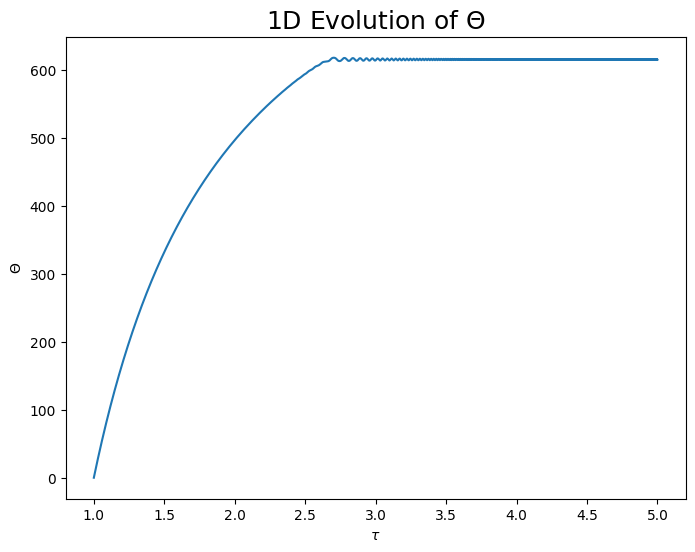

In [9]:
# Plot 1D evolution of θ
plt.figure(figsize = (8, 6))
plt.plot(tautab, theta1D)
plt.title(r"1D Evolution of $\Theta$", fontsize = 18)
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\Theta$')
plt.show()

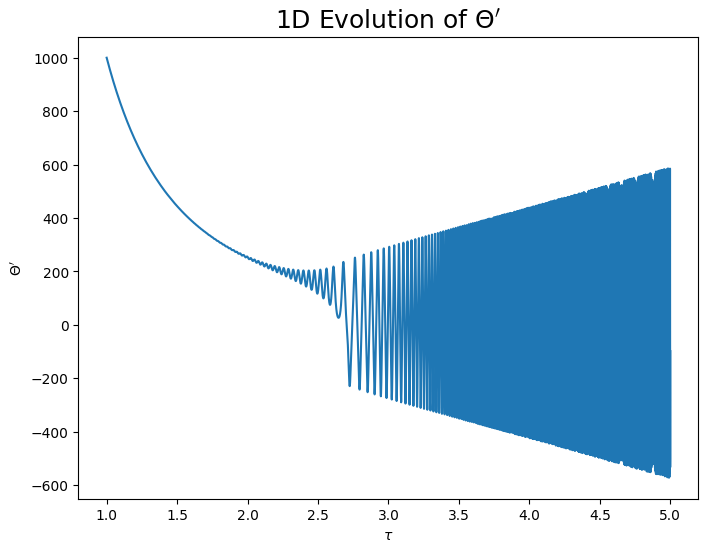

In [10]:
# Plot 1D evolution of θ'
plt.figure(figsize = (8, 6))
plt.plot(tautab, vheta1D)
plt.title(r"1D Evolution of $\Theta'$", fontsize = 18)
plt.xlabel(r'$\tau$')
plt.ylabel(r"$\Theta'$")
plt.show()

## Lattice Simulations

In [11]:
# Simulation parameters
N = 64 # Points/dimension
L = 3 # Box length in L₁ units
msa = 1.0 # String resolution
tauf = 5.0 # End of simulation 

In [12]:
# Create initial conditions
genspec_kinetic_mis(N, L, theta1, vheta1, hom = True)
print('Initial conditions created.')

Initial conditions created.


In [13]:
# Run simulations
rank, jax = sg.simgen(N = N, L = L, msa = msa, zRANKS = 2, ctf = tauf, ic = 'spax', ict = 'spax', prec = 'single',
                      dev = 'cpu', lap = 2, fftplan = 64, fA = fAGeV, vqcd = 'vqcdC', xtr = ' --ftype axion --mode0 1',
                      cti = 1, meas = 0, spKGV = 15, rmask = 4.0, p3D = 2, p2Dmap = True, p2DmapE = True, p2DmapPE = True, 
                      slc = N//2, nologmpi = True, verbose = 3, sIter = 5, verb = False, dump = 5, wDz = 0.2)
    
sg.runsim(JAX = jax, RANK = rank, THR = 16//rank, USA = '', VERB = False, BONDEN = True)
    
os.system('mv axion.log.0 log-run.txt initialspectrum.dat out')



--------------------------------------------------------------------------------------------
Mode: run 

Overview: N=64, MPI_RANKS=2, L=3.000000, msa=1.000000


rm: cannot remove 'out/m/axion.m.*': No such file or directory



Done!
--------------------------------------------------------------------------------------------


0

In [14]:
# Load measurement file
path = os.getcwd()
file_path = "/out"
mf = pa.findmfiles(path +  file_path)

In [15]:
tautab_sim = pa.gml(mf, 'ct') # Conformal times 
R = pa.gml(mf, 'R') # Scale factor in R₁
T = pa.gml(mf,'T') # Temperature in MeV
theta_maps = pa.gml(mf, 'maptheta') # Field values
vheta_maps = (pa.gml(mf, 'mapvheta')-theta_maps)/R_sim[:, None, None] # Velocity w.r.t. conformal time
mA = pa.gml(mf,'massA') # Axion mass, conformal mass: ma*r
eA = pa.gml(mf,'eA') # Axion energy

NameError: name 'R_sim' is not defined

In [ ]:
# Zero mode (average)
theta_avg = []  
vheta_avg = []

for i in np.arange(len(theta_maps)):
    theta_avg.append(np.mean(theta_maps[i]))
    vheta_avg.append(np.mean(vheta_maps[i]))
    
theta_avg = np.asarray(theta_avg)
vheta_avg = np.asarray(vheta_avg)

In [ ]:
# Plot lattice simulation evolution of θ
plt.figure(figsize = (8, 6))
plt.plot(tautab_sim, theta_avg)
plt.title(r"Lattice Simulation Evolution of $\Theta$", fontsize = 18)
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\Theta$')
plt.show()

In [ ]:
# Plot simulation evolution of θ'
plt.figure(figsize = (8, 6))
plt.plot(tautab_sim, vheta_avg)
plt.title(r"Lattice Simulation Evolution of $\Theta'$", fontsize = 18)
plt.xlabel(r'$\tau$')
plt.ylabel(r"$\Theta'$")
plt.show()

## Comparison

In [ ]:
# Plot comparison of evolution of θ
plt.figure(figsize = (8, 6))
plt.plot(tautab, theta1D, label = '1D')
plt.plot(tautab_sim, theta_avg, label = 'Lattice', linestyle = '--')
plt.title(r"Comparison of Evolution of $\Theta$", fontsize = 18)
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\Theta$')
plt.legend()
plt.show()

In [ ]:
# Plot comparison of evolution of θ'
plt.figure(figsize = (8, 6))
plt.plot(tautab, vheta1D, label = '1D')
plt.plot(tautab_sim, vheta_avg, label = 'Lattice', linestyle = '--')
plt.title(r"Comparison of Evolution of $\Theta'$", fontsize = 18)
plt.xlabel(r'$\tau$')
plt.ylabel(r"$\Theta'$")
plt.legend()
plt.show()

In [ ]:
fig, ax = plt.subplots(2, figsize = (12, 6), sharex = True)
fig.suptitle(r"Comparison of Evolution of $\Theta$ and $\Theta'$", fontsize = 16)

ax[0].plot(tautab, theta1D,label = '1D', zorder = 1)
ax[0].scatter(tautab_sim[::20], theta_avg[::20], marker = '.', s = 5, label = 'Lattice', c = 'red')
ax[1].plot(tautab, vheta1D, label = '1D', zorder = 1)
ax[1].scatter(tautab_sim[::10], vheta_avg[::10], marker = '.', s = 5, label = 'Lattice', c = 'red')


ax[1].set_xlabel(r'$\tau$')
ax[0].set_ylabel(r'$\Theta$')
ax[1].set_ylabel(r'$\Theta^\prime$')
plt.show()

## Abundance

In [ ]:
# Plot evolution of energy density parameter
plt.figure(figsize = (8, 6))
plt.title(r"Evolution of $\Omega_{A}h^2$", fontsize = 18)
plt.loglog(tautab, result1D['Omegah2tab'])
plt.axhline(0.12, color = 'k', ls = '--')
plt.xlabel(r'$\tau$')
plt.ylabel(r"$\Omega_{A}h^2$")
plt.show()

## Entropy Conservation

In [ ]:
# Entropy density dof
gS = CubicSpline(1/np.array(result1D['TMeVtab']), np.array(result1D['gstab']))

In [ ]:
# Plot evolution of comoving entropy
plt.figure(figsize = (8, 6))
plt.title(r"Evolution of $S$", fontsize = 18)
plt.plot(R, gS(1/T)*(R*T/T[0])**3)
plt.xlabel(r'$R/R_1$')
plt.ylabel(r"$S$")
plt.show()

In [ ]:
# Plot evolution of number density 
plt.figure(figsize = (8, 6))
plt.title(r"Evolution of $n_{A}$", fontsize = 18)
plt.loglog(R, eA/mA*R**3)
plt.xlabel(r'$R/R_1$')
plt.ylabel(r"$n_A$")
plt.show()